Candidate ID: 71131

ST456 2026 WT Assessment 2

## 0. Set up

Imports used in the problems below

In [6]:
import numpy as np
import pandas as pd
import collections
import random
import re
import os
import math
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import keras_hub
from tensorflow.keras.layers import Embedding, GRU, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import keras_nlp

Data loading function

In [2]:
### Mounting google drive to pull/save data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
### Loading the text data (using code from seminar 7)

filename = "/content/drive/MyDrive/Colab Notebooks/ST456 Deep Learning/Assessment 2/Lewis-Carroll-book.txt"

# data loading function
def read_time_machine():
    """Load the time machine dataset into a list of text lines."""
    with open(filename, 'r') as f:
        lines = f.readlines()
    # ignores punctuation and capitalization when preprocessing the raw text
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()

# initial data exploratory analysis
print(f'Number of text lines: {len(lines)}\n')
for i in range(15):
  print(lines[i])

Number of text lines: 3761

the project gutenberg ebook of alice s adventures in wonderland by lewis carroll

this ebook is for the use of anyone anywhere in the united states and
most other parts of the world at no cost and with almost no restrictions
whatsoever you may copy it give it away or re use it under the terms
of the project gutenberg license included with this ebook or online at
www gutenberg org if you are not located in the united states you
will have to check the laws of the country where you are located before
using this ebook

title alice s adventures in wonderland

author lewis carroll

release date january ebook


# **P1 - Recurrent Neural Networks**

*The task is to implement, train, and evaluate a character-level language model according to a GRU RNN. The input dataset is the text of the book Alice's Adventures in Wonderland by Lewis Carroll, which consists of 3,761 lines of text and 164,047 characters.*


### **P1.1:**

Transform the given text data such that each character is represented by a unique integer. Create a vocabulary. Print the data size (number of characters). Print the vocabulary size (number of distinct characters). Create a dataset made of sequences of consecutive 50 tokens. Split the transformed text data into inputs and targets as follows: for each sequence, duplicate it and shift it to form the input and target sequences.

In [ ]:
### Transform the text data to represent each character by a unique integer and create the vocabulary

# Using Keras Tokenizer to convert text to characters
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(lines)

# Check number of distinct tokens
len(tokenizer.word_index)

# Convert each character to a unique integer
token_list = []
for line in lines:
    # convert lines into a sequence of tokens
    seq = tokenizer.texts_to_sequences([line])[0]
    token_list.append(seq)

In [ ]:
### Print the data size and vocab size

# Total number of characters (not including symbols/punctuations)
total_char = sum(len(line) for line in token_list)
print('Data size (i.e., total number of characters), not including symbols/punctuations:', total_char)

# Number of distinct characters
total_distinct_char = len(tokenizer.word_index) + 1
print('Vocab size (i.e., total number of distinct characters), not including symbols/punctuations:', total_distinct_char)

Data size (i.e., total number of characters), not including symbols/punctuations: 151369
Vocab size (i.e., total number of distinct characters), not including symbols/punctuations: 28


In [ ]:
### Dataset made of sequences of consecutive 50 tokens

# Flattened token list
flat_token_list = [token for line in token_list for token in line]
print(len(flat_token_list))

# Create dataset of sequences of consecutive 50 tokens
row_size = 50
dataset = []

for i in range(0, total_char, row_size):
    each_row = flat_token_list[i:i+row_size+1]
    each_row = pad_sequences([each_row], maxlen=row_size, padding='post')[0] # padded extra to account for shift later for targets
    dataset.append(each_row)

# # Turn dataset into a 2D array
dataset = np.array(dataset)

# Check shape of datset
print("Shape of dataset:", dataset.shape, "\n")

# Preview dataset
print("First 3 rows of of dataset:\n", dataset[:3], "\n") # preview first 3 rows
print("Last row of dataset:\n", dataset[-1:]) # preview last row (check that padded 0s are there)

151369
Shape of dataset: (3028, 50) 

First 3 rows of of dataset:
 [[ 8  2  1 20 10  5 24  2 14  3  1 16 13  3  2  7 21  2 10 16  1  2 21  5
   5 22  1  5 19  1  4 12  6 14  2  1  9  1  4 11 23  2  7  3 13 10  2  9
   1  6]
 [ 7  1 15  5  7 11  2 10 12  4  7 11  1 21 17  1 12  2 15  6  9  1 14  4
  10 10  5 12 12  3  8  6  9  1  2 21  5  5 22  1  6  9  1 19  5 10  1  3
   8  2]
 [ 1 13  9  2  1  5 19  1  4  7 17  5  7  2  1  4  7 17 15  8  2 10  2  1
   6  7  1  3  8  2  1 13  7  6  3  2 11  1  9  3  4  3  2  9  1  4  7 11
  18  5]] 

Last row of dataset:
 [[ 4 10  1  4 21  5 13  3  1  7  2 15  1  2 21  5  5 22  9  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]]


In [ ]:
### Split the transformed text data into inputs and targets as follows: for each sequence, duplicate it and shift it to form the input and target sequences

inputs = dataset[:, :-1]
targets = dataset[:, 1:]

# Preview inputs and targets
print("Shape of inputs:", inputs.shape, "\n")
print("Inputs preview:\n", inputs[:2], "\n")
print("Shape of targets:", targets.shape, "\n")
print("Targets preview:\n", targets[:2])

Shape of inputs: (3028, 49) 

Inputs preview:
 [[ 8  2  1 20 10  5 24  2 14  3  1 16 13  3  2  7 21  2 10 16  1  2 21  5
   5 22  1  5 19  1  4 12  6 14  2  1  9  1  4 11 23  2  7  3 13 10  2  9
   1]
 [ 7  1 15  5  7 11  2 10 12  4  7 11  1 21 17  1 12  2 15  6  9  1 14  4
  10 10  5 12 12  3  8  6  9  1  2 21  5  5 22  1  6  9  1 19  5 10  1  3
   8]] 

Shape of targets: (3028, 49) 

Targets preview:
 [[ 2  1 20 10  5 24  2 14  3  1 16 13  3  2  7 21  2 10 16  1  2 21  5  5
  22  1  5 19  1  4 12  6 14  2  1  9  1  4 11 23  2  7  3 13 10  2  9  1
   6]
 [ 1 15  5  7 11  2 10 12  4  7 11  1 21 17  1 12  2 15  6  9  1 14  4 10
  10  5 12 12  3  8  6  9  1  2 21  5  5 22  1  6  9  1 19  5 10  1  3  8
   2]]


### **P1.2:**

Implement an RNN that consists of an embedding layer, followed by a GRU layer, and then followed by an output layer. Let the dimension of embeddings be 256 and dimension of hidden units be 1024. Show the model summary.

In [ ]:
### Setting hyperperameters

input_len = 49 # since each sequence length is 50
emb_dim = 256
num_hiddens = 1024

In [ ]:
### Create the RNN model with: embedding layer -> GRU layer -> output layer

model = Sequential()

# Add input embedding layer
model.add(Embedding(total_distinct_char, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
model.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
model.add(Dense(total_distinct_char, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### **P1.3:**

Train the model by using Adam optimiser with learning rate 1e-2 and the cross-entropy loss function. Train the model for 50 epochs. Record the mean loss for each epoch. Show the plot of loss function values versus the number of epochs. At the beginning of each epoch, shuffle the data and then split in batches of size 64. For the GRU layer, use the Glorot uniform initialiser. Use perplexity as a performance metric. Discuss the results.

In [ ]:
### Setting hyperparameters
learn_rt = 1e-2
n_epochs = 50
batch = 64

In [ ]:
### Setting up perplexity as a performance metric
perplexity = keras_hub.metrics.Perplexity(mask_token_id=0, name="perplexity")

In [ ]:
### Train the model with Adam optimizer, learning rate 1e-2, 50 epochs; note: GRU layer uses Glorot uniform initialiser above

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Train the model
history = model.fit(inputs, targets, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 3.9620 - perplexity: 52.4058
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 2.2205 - perplexity: 9.2041
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 2.0876 - perplexity: 8.0682
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.9871 - perplexity: 7.2966
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.9215 - perplexity: 6.8330
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.8645 - perplexity: 6.4542
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.8250 - perplexity: 6.2043
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.7925 - perplexity: 6.0057
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.7663 - perplexity: 5.8507
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.7466 - perplexity: 5.7366
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.7213 - perplexity: 5.5930
Epoch 12/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 

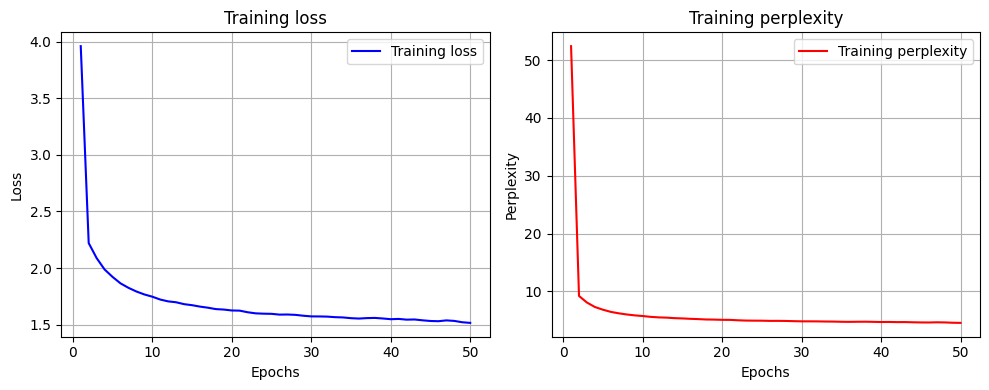

In [ ]:
### Plot of loss function values versus the number of epochs

# Using perplexity as a performance metric
loss = history.history['loss']
perplex = history.history['perplexity']
plot_epochs = range(1, len(loss) + 1)

# Plot training loss and training perplexity
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plotting training loss
# "b" is for "solid blue line"
axes[0].plot(plot_epochs, loss, 'b', label='Training loss')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid()

# Plotting training perplexity: Note - the graphs would be the same if used plt.yscale(value='log')
# "b" is for "solid blue line"
axes[1].plot(plot_epochs, perplex, 'r', label='Training perplexity')
axes[1].set_title('Training perplexity')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

#### **Results:**

- Training loss and perplexity decrease quickly, going down to around 1.5 and 4.5, respectively by the 50th epoch, though it is still slightly decreasing at that point
- Perplexity converges towards ~4.5 which is relatively low and means that the model chooses among ~4-5 different next tokens (characters), but this but could be improved to be closer to 1 for a more accurate string of characters to be produced
- There doesn't look to be signs of overfitting, as it convergs smoothly
- The model architecture is rather basic with just 3 layers and can be improved with such changes as adding more GRU layers, more hidden units, using a different RNN structure like LSTM, adding dropout, etc.

### **P1.4:**

After every 5 training epochs, generate an output text sequence of length 100 tokens by using the model trained up to the given point. Use character 'I' as the initial token. In order to make predictions, use a softmax to obtain probabilities, and output the most likely token. Try improving on results by modifying the architecture (e.g., make it a deep RNN, increase the hidden unit size). Discuss the obtained results. Save checkpoints every 5 epochs (hint: you may use `tf.train.Checkpoint` for that).

In [ ]:
### Functions adapted from Seminar 7

# predict the next token (character) given a seed character
def predict_next_token(seed_text, model_input, temperature=1.0):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    last_token = min(len(token_list), 49) - 1
    token_list_pad = pad_sequences([token_list], maxlen=49, padding='post')
    prediction = model_input.predict(token_list_pad, verbose=0)
    next_token = np.argmax(prediction[0, last_token, :])
    return next_token

## generate lines of text (sequence of characters) of arbitrary length (given by next_char)
def generate_text(seed_text, model_input, next_chars=100):
    next_text = seed_text
    for _ in range(next_chars):
        # predict next token
        prediction = predict_next_token(seed_text, model_input)
        # convert token to character
        next_char = tokenizer.sequences_to_texts([[prediction]])[0]
        # add next character to the line of text, which is then used in the next pass of the loop
        next_text += next_char
        seed_text += next_char # add to seed_text for next iteration
        seed_text = seed_text[-49:] # keep last 49 characters
    # return next characters
    return next_text

In [ ]:
### Testing out the predictive functions
prediction = predict_next_token(seed_text="I", model_input=model)
print(prediction)

generated = generate_text(seed_text="I", model_input=model, next_chars=100)
print(generated)

7
Ing and she said the said the said the said the said the queen s the proplet she she she said the cat


In [ ]:
### Create a custom callback in order to generate output after every 5 epochs

class CustomCallback5Epochs(keras.callbacks.Callback):
    def __init__(self, checkpoint_manager, model_input, seed_text="I", next_chars=100):
        self.manager = checkpoint_manager
        self.model_input = model_input
        self.seed_text = seed_text
        self.next_chars = next_chars

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0: # if next epoch is a multiple of 5
            # Save the checkpoint
            self.manager.save()
            print(f"\nCheckpoint saved at epoch {epoch + 1}")

            # Generate lines of text
            generated = generate_text(self.seed_text, self.model_input, self.next_chars)
            print(f"\nGenerated lines of text after epoch {epoch + 1}:")
            print(generated)

In [ ]:
### Generating output text sequence after every 5 training epochs - using the base model

# Base model:
model_1 = Sequential()

# Add input embedding layer
model_1.add(Embedding(total_distinct_char, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
model_1.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
model_1.add(Dense(total_distinct_char, activation='softmax'))
model_1.summary()

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
model_1.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_1, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs(checkpoint_manager=mngr, model_input=model_1, seed_text="I", next_chars=100)
history = model_1.fit(inputs, targets, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 3.8333 - perplexity: 14.4655
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 2.1467 - perplexity: 8.5367
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.9993 - perplexity: 7.3743
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.8891 - perplexity: 6.6150
Epoch 5/50
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.8342 - perplexity: 6.2623
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Ing the could the could the could the could the could the could the could the could the could the cou
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - loss: 1.8092 - perplexity: 6.1072
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.7557 - perplexity: 5.7893
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.7123 - perplexity: 5.5430
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.6853 - perplexity: 5.3955
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - lo

In [ ]:
### Updating the base model: adding another GRU layer (with 2048 units)

# Improved model:
model_2 = Sequential()

# Add input embedding layer
model_2.add(Embedding(total_distinct_char, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
model_2.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Change: Add another GRU layer with 2048 units (instead of 1024)
model_2.add(GRU(2048, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
model_2.add(Dense(total_distinct_char, activation='softmax'))
model_2.summary()

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
model_2.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_2, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs(checkpoint_manager=mngr, model_input=model_2, seed_text="I", next_chars=100)
history = model_2.fit(inputs, targets, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_12 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - loss: 9.9830 - perplexity: 4590.4141 
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - loss: 2.9433 - perplexity: 18.9042
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - loss: 2.6905 - perplexity: 14.6859
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - loss: 2.5613 - perplexity: 12.8969
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 2.4824 - perplexity: 11.9490
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
It the the the the the the the the the the the the the the the the the the the the the the the the th
48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 370ms/step - loss: 2.4584 - perplexity: 11.6449
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - loss: 2.3902 - perplexity: 10.8707
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - loss: 2.3543 - perplexity: 10.4939
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 2.3128 - perplexity: 10.0628
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━

In [ ]:
### Updating the base model: using more hidden units (2048 vs 1024)

# Base model:
model_3 = Sequential()

# Add input embedding layer
model_3.add(Embedding(total_distinct_char, emb_dim, input_length=input_len))

# Change: Having more hidden units (2048 vs 1024)
model_3.add(GRU(2048, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
model_3.add(Dense(total_distinct_char, activation='softmax'))
model_3.summary()

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
model_3.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_3, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs(checkpoint_manager=mngr, model_input=model_3, seed_text="I", next_chars=100)
history = model_3.fit(inputs, targets, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - loss: 5.0794 - perplexity: 52.7917
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 2.6106 - perplexity: 13.6072
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 2.4289 - perplexity: 11.3505
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 2.3798 - perplexity: 10.8068
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 2.3628 - perplexity: 10.6267
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Ing and and and and and and and and and and and and the the the the the the the the the the the the t
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 345ms/step - loss: 2.3365 - perplexity: 10.3490
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 2.3307 - perplexity: 10.2887
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 2.3524 - perplexity: 10.5149
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 2.2476 - perplexity: 9.4680
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6

In [ ]:
### Updating the base model: lowering the learning rate to 1e-3

# Improved model:
model_4 = Sequential()

# Add input embedding layer
model_4.add(Embedding(total_distinct_char, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
model_4.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
model_4.add(Dense(total_distinct_char, activation='softmax'))
model_4.summary()

# Compile the model; Change: learning_rate=1e-3 instead of 1e-2
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_4.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_4, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs(checkpoint_manager=mngr, model_input=model_4, seed_text="I", next_chars=100)
history = model_4.fit(inputs, targets, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 2.8623 - perplexity: 9.3097
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 2.2470 - perplexity: 9.4587
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.0801 - perplexity: 8.0063
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.9384 - perplexity: 6.9490
Epoch 5/50
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.8446 - perplexity: 6.3280
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Ing the project gutenberg the project gutenberg the project gutenberg the project gutenberg the proje
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - loss: 1.8116 - perplexity: 6.1214
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 1.6992 - perplexity: 5.4706
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.5990 - perplexity: 4.9493
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.5085 - perplexity: 4.5208
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - los

In [ ]:
### Updating the base model: adding a dropout layer

# Base model:
model_5 = Sequential()

# Add input embedding layer
model_5.add(Embedding(total_distinct_char, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
model_5.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Change: Add dropout
model_5.add(Dropout(0.1))

# Add output layer
model_5.add(Dense(total_distinct_char, activation='softmax'))
model_5.summary()

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
model_5.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_5, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs(checkpoint_manager=mngr, model_input=model_5, seed_text="I", next_chars=100)
history = model_5.fit(inputs, targets, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 4.4069 - perplexity: 9.7451
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.4762 - perplexity: 11.8435
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.3184 - perplexity: 10.1417
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 2.2348 - perplexity: 9.3463
Epoch 5/50
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.1885 - perplexity: 8.9251
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Ithe cout the projece the projece the could the preace the could the cout the center the could the co
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 237ms/step - loss: 2.1674 - perplexity: 8.7385
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 2.1093 - perplexity: 8.2454
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 2.0569 - perplexity: 7.8238
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 2.0087 - perplexity: 7.4562
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - l

In [ ]:
### Updating the base model: using more hidden units (2048 vs 1024) and a dropout layer

# Base model:
model_6 = Sequential()

# Add input embedding layer
model_6.add(Embedding(total_distinct_char, emb_dim, input_length=input_len))

# Change: Having more hidden units (2048 vs 1024)
model_6.add(GRU(2048, return_sequences=True, kernel_initializer='glorot_uniform'))

# Change: Add dropout
model_6.add(Dropout(0.1))

# Add output layer
model_6.add(Dense(total_distinct_char, activation='softmax'))
model_6.summary()

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
model_6.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_6, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs(checkpoint_manager=mngr, model_input=model_6, seed_text="I", next_chars=100)
history = model_6.fit(inputs, targets, epochs=50, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - loss: 7.4896 - perplexity: 82.8195
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 2.7442 - perplexity: 15.5537
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 2.4766 - perplexity: 11.9010
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 2.4041 - perplexity: 11.0700
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 2.3793 - perplexity: 10.8010
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
In the the the the the the the the the the the the the the the the the the the the the the the the th
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 360ms/step - loss: 2.3554 - perplexity: 10.5438
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 2.3169 - perplexity: 10.1462
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - loss: 2.2798 - perplexity: 9.7777
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 2.2352 - perplexity: 9.3503
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5

#### **Results:**

From the 6 models above, the following are the training losses and perplexities by the 50th epoch:


| Model   | Architecture Changes                                     | Loss   | Perplexity |
|---------|----------------------------------------------------------|--------|------------|
| Model 1 | Base model                                               | 1.4963 | 4.4664     |
| Model 2 | + Additional GRU layer (2048 units)                      | 1.8007 | 6.0555     |
| Model 3 | + Increased hidden units (2048 vs 1024)                  | 1.5997 | 4.9532     |
| Model 4 | with smaller learning rate (1e-3 vs 1e-2)                | 0.1510 | 1.1630     |
| Model 5 | + Dropout                                                | 1.3458 | 3.8424     |
| Model 6 | + Increased hidden units (2048) + Dropout                | 6.9527 | 1044.0437  |


- Compared to the base model, increasing the number of hidden units (Model 3) is roughly the same, while adding a dropout layer slightly decreased it, but only decreasing the learning rate (Model 4) led to a significant improvement. Increasing the hidden units and adding a dropout layer (Model 6) actually had a large increase in loss and perplexity after 48 epochs, indicating that this model is not stable and began overfitting towards the end.

- Across the models, the "coherence" of the generated string of characters generally improved over epochs, though for the poorer-performing models, some of them remained incoherent (i.e., Model 2, Model 5). They even started to increase in loss and perplexity (e.g., Model 5's perplexity went down to ~4.8  around 30 epochs but increased to >29 by the 50th epoch).

- Some got stuck at certain characters, repeating the same words over and over, e.g.:
  - Model 1, at epoch 50: *Ing the dormouse she said the dodshout she said the door like and she said the cat she said the door*
  - Model 2, at epoch 50: *It the the the the the the the the the the the the the the the the the the the the the the the the th*
  - Model 5, at epoch 50: *Ing the cat said the cat s all about she was she s not said the king some with a can be a box the pro*

- For the beset performing model (Model 4), the string of characters by the 50th epoch was: *Ing to but it was too dark to see anything then she had looking at the place where you are located be*
  - This had the most varied vocabulary of words and didn't fall into the same trap of repreating words or characters as in other models, and certain fragments are "coherent" (e.g., "but it was too dark to see anything"), but the set of characters/words still don't actually make sense

- Given it's at a character level, it would be more difficult to string together multiple words/full sentences that make sense. Other changes like potentially lengthening the input and target rows (i.e., from 49 to 79) could perhaps make the predictive nature better.

# **P2 - Word-level language model**

### **P2.1:**

Adapt the above pipeline to work on word-level tokens, as opposed to characters. Generate sentences starting from 'Alice' as the initial token. Discuss the results.

***The following are the same setups as for P1.1-P1.3 except the tokens are words instead of characters.***

In [ ]:
### Transform the text data to represent each **word** by a unique integer and create the vocabulary

# Using Keras Tokenizer to convert text to words
tokenizer_words = Tokenizer() # removed char_level=True
tokenizer_words.fit_on_texts(lines)

# Check number of distinct tokens
len(tokenizer_words.word_index)

# Convert each word to a unique integer
token_word_list = []
for line in lines:
    # convert lines into a sequence of tokens
    seq = tokenizer_words.texts_to_sequences([line])[0]
    token_word_list.append(seq)

In [ ]:
### Print the data size and vocab size

# Total number of words (not including symbols/punctuations)
total_word = sum(len(line) for line in token_word_list)
print('Data size (i.e., total number of words), not including symbols/punctuations:', total_word)

# Number of distinct words
total_distinct_word = len(tokenizer_words.word_index) + 1
print('Vocab size (i.e., total number of distinct words), not including symbols/punctuations:', total_distinct_word)

Data size (i.e., total number of words), not including symbols/punctuations: 30564
Vocab size (i.e., total number of distinct words), not including symbols/punctuations: 3007


In [ ]:
### Dataset made of sequences of consecutive 50 tokens

# Flattened token list
flat_token_word_list = [token for line in token_word_list for token in line]
len(flat_token_word_list)

# Create dataset of sequences of consecutive 50 tokens
row_size = 50
dataset_word = []

for i in range(0, total_word, row_size):
    each_row = flat_token_word_list[i:i+row_size+1]
    each_row = pad_sequences([each_row], maxlen=row_size, padding='post')[0] # padded extra to account for shift later for targets
    dataset_word.append(each_row)

# # Turn dataset into a 2D array
dataset_word = np.array(dataset_word)

# Check shape of datset
print("Shape of dataset:", dataset_word.shape, "\n")

# Preview dataset
print("First 3 rows of of dataset:\n", dataset_word[:3], "\n") # preview first 3 rows
print("Last row of dataset:\n", dataset_word[-1:]) # preview last row (check that padded 0s are there)

Shape of dataset: (612, 50) 

First 3 rows of of dataset:
 [[  49   45  307    5   12   19  358   11  534   53  940  941   23  307
    34   24    1  151    5  665  942   11    1  265  224    2  285   87
   943    5    1  423   18   44  770    2   17  465   44 1210 1211    9
   172  335    6  250    6  173   29  129]
 [ 151    6  201    1  196    5    1   49   45  231  944   17   23  307
    29  771   18  384   45  385   37    9   62   27  535   11    1  265
   224    9  125   52    3  772    1  386    5    1  666  218    9   62
   535  126  466   23  307 1685   12   19]
 [ 358   11  534 1686  940  941 1687  945 1688  307  285 1689 1212 1690
  1691  536 1213  197 1692 1693  946   53 1694 1695    2 1696 1697  947
     5    1   49   45  307   12   19  358   11  534 1698   12   19  358
    11  534   53  940  941    1 1699 1700]] 

Last row of dataset:
 [[ 595    2   68    3 3005    3  354 1682 3006    3  267   42  480  595
     0    0    0    0    0    0    0    0    0    0    0    0    0 

In [ ]:
### Split the transformed text data into inputs and targets as follows: for each sequence, duplicate it and shift it to form the input and target sequences

inputs_word = dataset_word[:, :-1]
targets_word = dataset_word[:, 1:]

# Preview inputs and targets
print("Shape of inputs:", inputs_word.shape, "\n")
print("Inputs preview:\n", inputs_word[:2], "\n")
print("Shape of targets:", targets_word.shape, "\n")
print("Targets preview:\n", targets_word[:2])

Shape of inputs: (612, 49) 

Inputs preview:
 [[  49   45  307    5   12   19  358   11  534   53  940  941   23  307
    34   24    1  151    5  665  942   11    1  265  224    2  285   87
   943    5    1  423   18   44  770    2   17  465   44 1210 1211    9
   172  335    6  250    6  173   29]
 [ 151    6  201    1  196    5    1   49   45  231  944   17   23  307
    29  771   18  384   45  385   37    9   62   27  535   11    1  265
   224    9  125   52    3  772    1  386    5    1  666  218    9   62
   535  126  466   23  307 1685   12]] 

Shape of targets: (612, 49) 

Targets preview:
 [[  45  307    5   12   19  358   11  534   53  940  941   23  307   34
    24    1  151    5  665  942   11    1  265  224    2  285   87  943
     5    1  423   18   44  770    2   17  465   44 1210 1211    9  172
   335    6  250    6  173   29  129]
 [   6  201    1  196    5    1   49   45  231  944   17   23  307   29
   771   18  384   45  385   37    9   62   27  535   11    1  265  2

In [ ]:
### Using the same hyperperameters

input_len = 49 # since each sequence length is 50
emb_dim = 256
num_hiddens = 1024

In [ ]:
### Use the same base RNN model with: embedding layer -> GRU layer -> output layer

modelb = Sequential()

# Add input embedding layer
modelb.add(Embedding(total_distinct_word, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
modelb.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
modelb.add(Dense(total_distinct_word, activation='softmax'))
modelb.summary()

### Train the model with Adam optimizer, learning rate 1e-2, 50 epochs; note: GRU layer uses Glorot uniform initialiser above
learn_rt = 1e-2
n_epochs = 50
batch = 64

# Use perplexity as a performance metric
# import keras_hub
perplexity = keras_hub.metrics.Perplexity(mask_token_id=0, name="perplexity")

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
modelb.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Train the model
history = modelb.fit(inputs_word, targets_word, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_16 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 7.5245 - perplexity: 1842.4144
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 8.0618 - perplexity: 3122.6709
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 10.1640 - perplexity: 25877.4473
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 8.9025 - perplexity: 7368.4844
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 7.9649 - perplexity: 2890.3596
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 7.3590 - perplexity: 1581.4214
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 6.9266 - perplexity: 1027.3748
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 6.6587 - perplexity: 779.8548
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 6.4821 - perplexity: 658.5380
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 6.3605 - perplexity: 579.7057
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 6.2607 - perplexity: 527.5709
Epoch 12/5

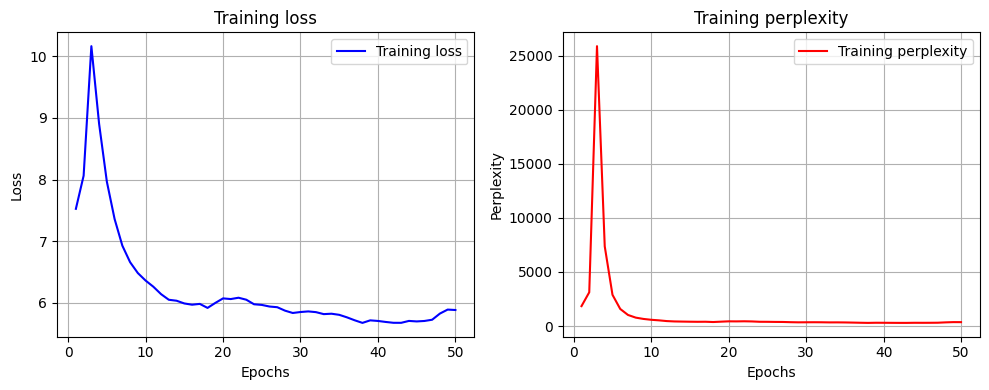

In [ ]:
### Plot of loss function values versus the number of epochs

# Using perplexity as a performance metric
loss = history.history['loss']
perplex = history.history['perplexity']
plot_epochs = range(1, len(loss) + 1)

# Plot training loss and training perplexity
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plotting training loss
# "b" is for "solid blue line"
axes[0].plot(plot_epochs, loss, 'b', label='Training loss')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid()

# Plotting training perplexity: Note - the graphs would be the same if used plt.yscale(value='log')
# "b" is for "solid blue line"
axes[1].plot(plot_epochs, perplex, 'r', label='Training perplexity')
axes[1].set_title('Training perplexity')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [ ]:
### Running the same modelb again to illustrate the variable outputs of the same base RNN model with: embedding layer -> GRU layer -> output layer

modelb2 = Sequential()

# Add input embedding layer
modelb2.add(Embedding(total_distinct_word, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
modelb2.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
modelb2.add(Dense(total_distinct_word, activation='softmax'))
modelb2.summary()

### Train the model with Adam optimizer, learning rate 1e-2, 50 epochs; note: GRU layer uses Glorot uniform initialiser above
learn_rt = 1e-2
n_epochs = 50
batch = 64

# Use perplexity as a performance metric
# import keras_hub
perplexity = keras_hub.metrics.Perplexity(mask_token_id=0, name="perplexity")

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
modelb2.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Train the model
history = modelb2.fit(inputs_word, targets_word, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_18 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 7.8456 - perplexity: 2542.5818
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 7.6969 - perplexity: 2199.0237
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 6.7552 - perplexity: 843.9477 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 6.0414 - perplexity: 421.7152
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 5.5098 - perplexity: 248.4400
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 5.0583 - perplexity: 157.8644
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 4.7154 - perplexity: 112.0763
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 4.3503 - perplexity: 77.8387
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 4.0249 - perplexity: 55.9336
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 3.7025 - perplexity: 40.7084
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 3.4227 - perplexity: 30.7619
Epoch 12/50
10/10 ━━

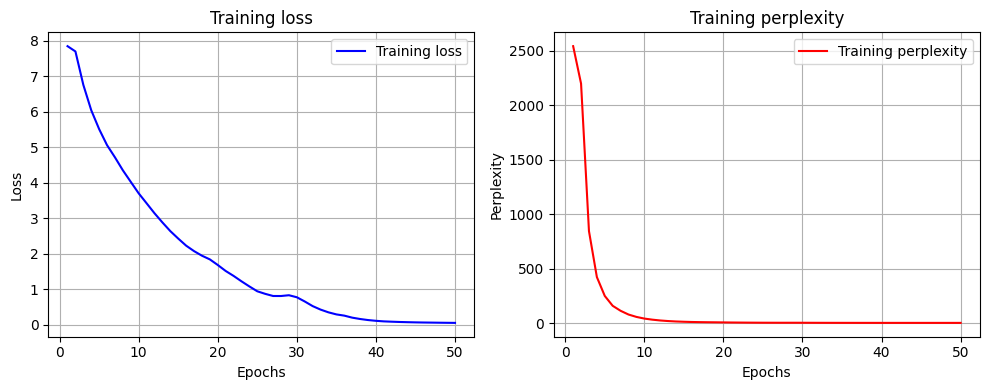

In [ ]:
### Plot of loss function values versus the number of epochs

# Using perplexity as a performance metric
loss = history.history['loss']
perplex = history.history['perplexity']
plot_epochs = range(1, len(loss) + 1)

# Plot training loss and training perplexity
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plotting training loss
# "b" is for "solid blue line"
axes[0].plot(plot_epochs, loss, 'b', label='Training loss')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid()

# Plotting training perplexity: Note - the graphs would be the same if used plt.yscale(value='log')
# "b" is for "solid blue line"
axes[1].plot(plot_epochs, perplex, 'r', label='Training perplexity')
axes[1].set_title('Training perplexity')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

#### **Results vs in P1:**

- The loss and perplexity spiked around the 3rd epoch when running this base model the first time (i.e., modelb), after which it decreases generally steadily, aside from some slight bumps
- When running this same model multiple times, the loss and perplexity can be quite variable.
  - For example, "modelb" spikes after a few epochs then declines, though its loss and perplexity wavers around epoch 19 and slightly increases towards the end, ending at the 50th epoch with a training loss of 5.8826 and training perplexity of 361.2028.
  - When running the same model once more, as in "modelb2", the model decreases immediately and quickly, with a slight plateau and even increase around epochs 27-29, then decreases again, ending at a training loss of 0.0559 and training perplexity of 1.0576.
- Since the vocab size increased from 28 (characters) to 3007 (words), which also means taht the output layer is larger (i.e., more units), it likely affected the performance in the model, and the gradients would be bigger and may have caused a spike in the first run of the model.
- As they then decreased steadily after a couple epochs, it illustrates that the model recovered and was learning properly afterwards.
- One change that could improve the model performance would be to lower the learning rate, as seen in P1's Model 4

***The following applies the changes from P1.4 to show the progress every 5 epochs, except only the base model and the best model from P1.4 are used.***

In [ ]:
### Updated functions to apply to word-level tokens

# predict the next token (word) given a seed word (same as above)
def predict_next_token_words(seed_text, model_input, temperature=1.0):
    token_list = tokenizer_words.texts_to_sequences([seed_text])[0]
    last_token = min(len(token_list), 49) - 1
    token_list_pad = pad_sequences([token_list], maxlen=49, padding='post')
    prediction = model_input.predict(token_list_pad, verbose=0)
    next_token = np.argmax(prediction[0, last_token, :])
    return next_token

## generate lines of text (sequence of words) of arbitrary length (given by next_word)
def generate_text_words(seed_text, model_input, next_words=100):
    next_text = seed_text
    seed_words = seed_text.split() # in case there are >1 seed_text in a list

    for _ in range(next_words):
        # predict next token
        prediction = predict_next_token_words(' '.join(seed_words), model_input)
        # convert token to word
        next_word = tokenizer_words.sequences_to_texts([[prediction]])[0]
        # add next word to the line of text, which is then used in the next pass of the loop
        next_text += ' ' + next_word
        seed_words.append(next_word) # add to seed_text for next iteration
        seed_words = seed_words[-49:] # keep last 49 words
    # return next words
    return next_text

In [ ]:
### Testing out the predictive functions
prediction = predict_next_token_words(seed_text="Alice", model_input=modelb)
print(prediction)

generated = generate_text_words(seed_text="Alice", model_input=modelb, next_words=100)
print(generated)

1008
Alice gently remarked him sighing went the place number of the mock turtle the mock turtle the mock turtle the mock the mock turtle the mock turtle and the gryphon and the gryphon and the gryphon and the gryphon and the gryphon and and and her so she she was and the choking of the gryphon hare join and large left the mock turtle and the executioner choice that project crowded on the lost toes choice uncomfortable crowded that mind wish replied crowded the duchess uncomfortable move lay uncomfortable gutenberg the court the flurry of stretched the queen the cat the


In [ ]:
### Create a custom callback in order to generate output after every 5 epochs - updated for words

class CustomCallback5Epochs_words(keras.callbacks.Callback):
    def __init__(self, checkpoint_manager, model_input, seed_text="I", next_words=100):
        self.manager = checkpoint_manager
        self.model_input = model_input
        self.seed_text = seed_text
        self.next_words = next_words

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0: # if next epoch is a multiple of 5
            # Save the checkpoint
            self.manager.save()
            print(f"\nCheckpoint saved at epoch {epoch + 1}")

            # Generate lines of text
            generated = generate_text_words(self.seed_text, self.model_input, self.next_words)
            print(f"\nGenerated lines of text after epoch {epoch + 1}:")
            print(generated)

In [ ]:
### Base model for words:

# Base model:
model_1b = Sequential()

# Add input embedding layer
model_1b.add(Embedding(total_distinct_word, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
model_1b.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
model_1b.add(Dense(total_distinct_word, activation='softmax'))
model_1b.summary()

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
model_1b.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_1b, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs_words(checkpoint_manager=mngr, model_input=model_1b, seed_text="Alice", next_words=100)
history = model_1b.fit(inputs_word, targets_word, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_19 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 7.6568 - perplexity: 47.1354
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 8.2981 - perplexity: 3920.9221
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 7.9971 - perplexity: 2970.3674
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 7.3812 - perplexity: 1587.8766
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 6.9012 - perplexity: 997.6605 
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Alice s the to to to tm to the gryphon of a of a of to behead to a to a to a to of to and to to to to to behead to to to to to behead to to to to to behead to to to and to to of the the queen of a of a the of a and the queen to a and i she a to the the queen she the the the the queen to the the the the queen to the the the the queen to the the queen to the the little
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 6.7801 - perplexity: 879.5127 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━

In [ ]:
### Base model for words + lowering the learning rate to 1e-3

# Improved model:
model_4b = Sequential()

# Add input embedding layer
model_4b.add(Embedding(total_distinct_word, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
model_4b.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
model_4b.add(Dense(total_distinct_word, activation='softmax'))
model_4b.summary()

# Compile the model; Change: learning_rate=1e-3 instead of 1e-2
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_4b.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_4b, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs_words(checkpoint_manager=mngr, model_input=model_4b, seed_text="Alice", next_words=100)
history = model_4b.fit(inputs_word, targets_word, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_20 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - loss: 7.7210 - perplexity: 239.9732
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 6.6445 - perplexity: 767.1326
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 6.4226 - perplexity: 615.2637
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 6.1975 - perplexity: 491.4614
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 6.1268 - perplexity: 457.9799
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Alice the of the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 6.0997 - perplexity: 445.6324 
Epoc

#### **Results:**

| Model   | Architecture Changes                                     | Loss   | Perplexity |
|---------|----------------------------------------------------------|--------|------------|
| Model 1 | Base model (words)                                       | 3.2419 | 25.6660    |
| Model 4 | with smaller learning rate (1e-3 vs 1e-2) (words)        | 0.7956 | 2.2179     |

- We saw that in "modelb" and "modelb2" that the outputs can be unsteady with the original hyperparameters and model architecture. In Model 1 with words, this iteration's output also initially spiked at the second epoch before steadily decreasing, though it landed at a training loss and training perplexity between the other two
- The training loss and perplexity was also much lower for the model with a smaller learning rate, similar to the one in the character-based models
- These models output 100 *words* instead of *characters* at every 5 epochs, and we can see there are different fragments of words that are coherent, but the overall sentence doesn't make sense:
  - E.g., for Model 1: "the mock turtle said"
  - E.g., for Model 4: "Alice gently remarked", "head over heels"
- There were some parts in Model 1 in which the words got stuck and repeated multiple times (e.g., "the mock turtle said the mock turtle said the mock turtle said the"), though it would eventually get out of the loop and onto other words (e.g., then followed by "gryphon")
- Further improvements could be made to decrease the perplexity (and loss) to have more accurate and coherent word predictions

### **P2.2:**

Use pre-trained static word embeddings, and re-train the network. Discuss and compare the results with the previous step.

#### *Get pre-trained static word embeddings - GloVe website, as in Seminar 8:*

In [ ]:
### Using the pre-trained embeddings from GloVe website, just as in Seminar 8

# Download the glove.6B.50d.txt from ST456 Dropbox
!rm -rf /content/*
!wget https://www.dropbox.com/scl/fi/qtzxwsugwvcxmvcqx8k0m/glove.6B.50d.txt?rlkey=93rltv6cwykl9v1ju9of2midb&dl=0
!mv glove.6B.50d.txt?rlkey=93rltv6cwykl9v1ju9of2midb glove.6B.50d.txt

# glove_embeddings dictionary
embeddings_dict = {}
# make sure to adjust the path accordingly
with open("/content/glove.6B.50d.txt", 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        token = values[0]
        vector = np.asarray(values[1:], "float32")
        embeddings_dict[token] = vector

rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
rm: cannot remove '/content/drive/.Encrypted/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.Encrypted/.shortcut-targets-by-id': Operation canceled
--2026-03-29 13:36:21--  https://www.dropbox.com/scl/fi/qtzxwsugwvcxmvcqx8k0m/glove.6B.50d.txt?rlkey=93rltv6cwykl9v1ju9of2midb
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uca48284ed6e6fc8c5691f828331.dl-eu.dropboxusercontent.com/cd/0/inline/C9nThMB-RC1YyVvaUB5MyhgGSj5ixs-xiukooIMGj1FXQXmDjeVx8aG8oc-sCF8-IDN4ESBzmjbXo1N7ZjvYVtB5wqYs2yJC9aNEZjynKnpV3d83U6EULs2RIh6lnd04-xvMT5dLbPd2mky6lOEQ8we4/file# [following]
--2026-03-29 13:36:22-- 

In [ ]:
# !pip install gensim # run this the first time

from gensim.test.utils import datapath, get_tmpfile
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# Replace 'path_to_glove_file/glove.6B.50d.txt' with your GloVe file path
glove_file = '/content/glove.6B.50d.txt'

# Convert GloVe format to Word2Vec format
word2vec_temp_file = get_tmpfile("/content/glove_word2vec.txt")
glove2word2vec(glove_file, word2vec_temp_file)

# Load GloVe embeddings using Gensim
glove_model = KeyedVectors.load_word2vec_format(word2vec_temp_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.4 MB/s eta 0:00:00


/tmp/ipykernel_375/465748430.py:12: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_file, word2vec_temp_file)


In [ ]:
### Test the usage
word = 'shore'
if word in glove_model:
    embedding = glove_model[word]
    print(f"Embedding for '{word}': {embedding}")
else:
    print(f"'{word}' not found in embeddings")

print('\n')

word1 = 'shore'
word2 = 'queen'
similarity = glove_model.similarity(word1, word2)
print(f"Similarity between '{word1}' and '{word2}': {similarity}")

print('\n')

word3 = 'Alice'
if word3 in glove_model:
    embedding = glove_model[word3]
    print(f"Embedding for '{word3}': {embedding}")
else:
    print(f"'{word3}' not found in embeddings")

Embedding for 'shore': [ 0.83992   0.43553   0.037458 -0.33084  -0.67501  -0.34947  -1.0518
  0.72262   0.37621  -0.83577  -0.68345   0.18016   0.80724   0.11852
 -1.2675    0.27401   0.90135   0.16743  -0.86033   0.10102   0.68965
  0.20964  -0.29048  -0.027251  0.27364  -1.1416    0.39114   0.55095
  0.27477  -0.31956   2.3802    0.08895   0.48059   0.027629  0.093566
 -0.055857 -0.81898  -0.48999   0.25013  -0.4233   -0.41523  -0.096811
  0.79106  -0.41257  -0.53197  -0.17196  -0.032178 -0.63185   0.08561
 -0.067809]


Similarity between 'shore' and 'queen': 0.3952700197696686


'Alice' not found in embeddings


In [ ]:
### Transform the text data to represent each word by a unique integer and create the vocabulary

# Using Keras Tokenizer to convert text to words
tokenizer_static = tf.keras.preprocessing.text.Tokenizer()
tokenizer_static.fit_on_texts(lines)

# Check number of distinct tokens
len(tokenizer_static.word_index)

# Convert each word to a unique integer
token_static_list = []
for line in lines:
    # convert lines into a sequence of tokens
    seq = tokenizer_static.texts_to_sequences([line])[0]
    token_static_list.append(seq)

# checking some samples
print(tokenizer_static.sequences_to_texts(token_static_list[:5]))
token_static_list[:5]

['the project gutenberg ebook of alice s adventures in wonderland by lewis carroll', '', 'this ebook is for the use of anyone anywhere in the united states and', 'most other parts of the world at no cost and with almost no restrictions', 'whatsoever you may copy it give it away or re use it under the terms']


[[1, 49, 45, 307, 5, 12, 19, 358, 11, 534, 53, 940, 941],
 [],
 [23, 307, 34, 24, 1, 151, 5, 665, 942, 11, 1, 265, 224, 2],
 [285, 87, 943, 5, 1, 423, 18, 44, 770, 2, 17, 465, 44, 1210],
 [1211, 9, 172, 335, 6, 250, 6, 173, 29, 129, 151, 6, 201, 1, 196]]

In [ ]:
### Print the data size and vocab size

# Total number of words (not including symbols/punctuations)
total_static = sum(len(line) for line in token_static_list)
print('Data size (i.e., total number of words), not including symbols/punctuations:', total_static)

# Number of distinct words
total_distinct_static = len(tokenizer_static.word_index) + 1
print('Vocab size (i.e., total number of distinct words), not including symbols/punctuations:', total_distinct_static)

Data size (i.e., total number of words), not including symbols/punctuations: 30564
Vocab size (i.e., total number of distinct words), not including symbols/punctuations: 3007


In [ ]:
### Dataset made of sequences of consecutive 50 tokens

# Flattened token list
flat_token_static_list = [token for line in token_word_list for token in line]
len(flat_token_static_list)

# Create dataset of sequences of consecutive 50 tokens
row_size = 50
dataset_static = []

for i in range(0, total_word, row_size):
    each_row = flat_token_static_list[i:i+row_size+1]
    each_row = pad_sequences([each_row], maxlen=row_size, padding='post')[0] # padded extra to account for shift later for targets
    dataset_static.append(each_row)

# # Turn dataset into a 2D array
dataset_static = np.array(dataset_static)

# Check shape of datset
print("Shape of dataset:", dataset_static.shape, "\n")

# Preview dataset
print("First 3 rows of of dataset:\n", dataset_static[:3], "\n") # preview first 3 rows
print("Last row of dataset:\n", dataset_static[-1:]) # preview last row (check that padded 0s are there)

Shape of dataset: (612, 50) 

First 3 rows of of dataset:
 [[  49   45  307    5   12   19  358   11  534   53  940  941   23  307
    34   24    1  151    5  665  942   11    1  265  224    2  285   87
   943    5    1  423   18   44  770    2   17  465   44 1210 1211    9
   172  335    6  250    6  173   29  129]
 [ 151    6  201    1  196    5    1   49   45  231  944   17   23  307
    29  771   18  384   45  385   37    9   62   27  535   11    1  265
   224    9  125   52    3  772    1  386    5    1  666  218    9   62
   535  126  466   23  307 1685   12   19]
 [ 358   11  534 1686  940  941 1687  945 1688  307  285 1689 1212 1690
  1691  536 1213  197 1692 1693  946   53 1694 1695    2 1696 1697  947
     5    1   49   45  307   12   19  358   11  534 1698   12   19  358
    11  534   53  940  941    1 1699 1700]] 

Last row of dataset:
 [[ 595    2   68    3 3005    3  354 1682 3006    3  267   42  480  595
     0    0    0    0    0    0    0    0    0    0    0    0    0 

In [ ]:
### Split the transformed text data into inputs and targets as follows: for each sequence, duplicate it and shift it to form the input and target sequences

inputs_static = dataset_static[:, :-1]
targets_static = dataset_static[:, 1:]

# Preview inputs and targets
print("Shape of inputs:", inputs_static.shape, "\n")
print("Inputs preview:\n", inputs_static[:2], "\n")
print("Shape of targets:", targets_static.shape, "\n")
print("Targets preview:\n", targets_static[:2])

Shape of inputs: (612, 49) 

Inputs preview:
 [[  49   45  307    5   12   19  358   11  534   53  940  941   23  307
    34   24    1  151    5  665  942   11    1  265  224    2  285   87
   943    5    1  423   18   44  770    2   17  465   44 1210 1211    9
   172  335    6  250    6  173   29]
 [ 151    6  201    1  196    5    1   49   45  231  944   17   23  307
    29  771   18  384   45  385   37    9   62   27  535   11    1  265
   224    9  125   52    3  772    1  386    5    1  666  218    9   62
   535  126  466   23  307 1685   12]] 

Shape of targets: (612, 49) 

Targets preview:
 [[  45  307    5   12   19  358   11  534   53  940  941   23  307   34
    24    1  151    5  665  942   11    1  265  224    2  285   87  943
     5    1  423   18   44  770    2   17  465   44 1210 1211    9  172
   335    6  250    6  173   29  129]
 [   6  201    1  196    5    1   49   45  231  944   17   23  307   29
   771   18  384   45  385   37    9   62   27  535   11    1  265  2

#### *Retrain the network*

In [ ]:
### Using the same hyperperameters for model building/compiling/training
input_len = 49 # since each sequence length is 50
emb_dim_glove = 50 # GloVe embeddings' dimension need to match input file
num_hiddens = 1024

learn_rt = 1e-2
n_epochs = 50
batch = 64

In [ ]:
### GloVe embedding (adapted from Seminar 8)

# Create an embedding matrix
embedding_matrix = np.zeros((total_distinct_static, emb_dim_glove))

# Load GloVe embeddings
def load_glove_embeddings(file_path):
    embeddings = {}
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# Replace with your GloVe file path
glove_embeddings_path = '/content/glove.6B.50d.txt'
glove_embeddings = load_glove_embeddings(glove_embeddings_path)

In [ ]:
### GloVe weights matrix
for word, i in tokenizer_static.word_index.items():
    embedding_vector = glove_embeddings.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:
### Defining the model

# Create an Embedding layer
embedding_layer = tf.keras.layers.Embedding(
    input_dim=total_distinct_static,
    output_dim=emb_dim_glove,
    weights=[embedding_matrix],
    # Set to False to freeze GloVe embeddings
    trainable=False
)

In [ ]:
### Use the embedding layer in the TensorFlow base model

# Build the model
model_static = tf.keras.Sequential([
    embedding_layer,
    # Add GRU layer
    GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'),
    # Add coherent output layer
    Dense(total_distinct_static, activation='softmax')
])

model_static.summary()

# Compile the model
opt = tf.keras.optimizers.Adam(learning_rate=learn_rt)
model_static.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Include the checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_static, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs_words(checkpoint_manager=mngr, model_input=model_static,
                                             seed_text="Alice", next_words=100)
history = model_static.fit(inputs_word, targets_word, epochs=n_epochs, verbose=1,
                           batch_size=batch, shuffle=True, callbacks=[callback5epoch])

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ ?                      │       150,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_21 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,350 (587.30 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 150,350 (587.30 KB)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 8.7998 - perplexity: 120.2647
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 8.3115 - perplexity: 4070.0281
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 7.4542 - perplexity: 1718.6791
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 7.0553 - perplexity: 1156.8828
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 6.6348 - perplexity: 761.5896
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Alice childhood looked the the the the tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm tm the the the the the the the the the the the the the the the the of the the tm tm tm tm tm tm tm tm tm works tm tm tm tm the the the the the the the the the the the the work work the
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 6.6061 - perplexity: 739.3406 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/s

In [ ]:
### Base model for words + lowering the learning rate to 1e-3

# Improved model:
model_static4 = Sequential()

# Add input embedding layer
model_static4.add(Embedding(total_distinct_word, emb_dim, input_length=input_len))

# Add GRU layer with 1024 units
model_static4.add(GRU(num_hiddens, return_sequences=True, kernel_initializer='glorot_uniform'))

# Add output layer
model_static4.add(Dense(total_distinct_word, activation='softmax'))
model_static4.summary()

# Compile the model; Change: learning_rate=1e-3 instead of 1e-2
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)
model_static4.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model_static4, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the model (with checkpoints)
callback5epoch = CustomCallback5Epochs_words(checkpoint_manager=mngr, model_input=model_static4, seed_text="Alice", next_words=100)
history = model_static4.fit(inputs_word, targets_word, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_22 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 7.6532 - perplexity: 342.6193
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 6.6374 - perplexity: 762.1066
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 6.3816 - perplexity: 590.6540
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 6.1657 - perplexity: 476.0247
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 6.1037 - perplexity: 447.5665
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Alice the queen and the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 6.0727 - perplexity: 433.7680 
E

#### **Results:**


- As in part P2.1, the base model (model_static) has a generally higher training loss and training perplexity that varies when rerunning it, and after 45 epochs, its training loss and training perplexity started to increase

- For the model with lower training learning rate (Model 4), it marginally improved over the iteration in P2.1 (0.7545 vs. 0.7956 for training loss, 2.1287 vs 2.2179 for training perplexity), but not significantly

- However, based on reading the generated lines by the 50th epoch, this version in P2.2 does make a bit more sense and has longer fragments that are coherent (e.g., the bolded parts):

  - P2.1 version: *Alice gently remarked **she said to herself** in the house tone the march hare said the hatter **in a low voice** tone at the stick and tumbled head over heels in its mouth and addressed to the little door and then the door had to get in the court and the great hall with the glass table as the door opened inwards and alice s elbow while the moment alice went on **in the court** and this time to make her back into the last few minutes that she had never to get in the court but **it was rather doubtful***

  - P2.2 version: *Alice led to her rather inquisitively and **she felt that she had forgotten the first question** was the first she was not quite forgotten the look of the court and the other party had got into the dormouse and **she hurried off to the other side of the court** and she tucked her hand and she did not quite much larger and she was quite a curious dream one about and the dormouse was bristling all over and **she went back to the table** she said to herself it would be quite as she spoke and he hurried off to the*

# **P3 - Transformers**



### **P3.1:**

Replace the RNN with a decoder-only (causal) transformer architecture. Compare the results with the RNN.

In [ ]:
### Adapted the layers from Seminar 9 to apply for a decoder-only transformer

# Positional Embedding (with positional_encoding() within)
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.d_model = d_model
    self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True)
    self.pos_encoding = self.positional_encoding(length=2048, depth=d_model) # reference positional_encoding within

  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)
    #Simply calls self.embedding.compute_mask(), ensuring that the mask is correctly passed through the PositionalEmbedding layer

  def positional_encoding(self, length, depth): # put within the PositionalEmbedding() class
    depth = depth/2
    positions = np.arange(length)[:, np.newaxis]     # (seq, 1), token positions
    depths = np.arange(depth)[np.newaxis, :]/depth   # (1, depth), normalized depth indices (0 to 1)

    angle_rates = 1 / (10000**depths)         # (1, depth)
    angle_rads = positions * angle_rates      # (pos, depth)

    pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)],axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)

  def call(self, x):
    length = tf.shape(x)[1]
    x = self.embedding(x)
    # This factor sets the relative scale of the embedding and positonal_encoding.
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x = x + self.pos_encoding[tf.newaxis, :length, :]
    return x

# Base Attention Layer
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

# Causal Self-Attention Layer
class CausalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(query=x, value=x, key=x, use_causal_mask = True)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

# Feed-Forward Network
class FeedForward(tf.keras.layers.Layer):
  def __init__(self, d_model, dff, dropout_rate=0.1):
    super().__init__()
    self.seq = tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),
      tf.keras.layers.Dense(d_model),
      tf.keras.layers.Dropout(dropout_rate)
    ])
    self.add = tf.keras.layers.Add()
    self.layer_norm = tf.keras.layers.LayerNormalization()

  def call(self, x):
    x = self.add([x, self.seq(x)])
    x = self.layer_norm(x)
    return x

# Decoder Layer (without CrossAttention() since decoder-only)
class DecoderOnlyLayer(tf.keras.layers.Layer):
  def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
    super(DecoderOnlyLayer, self).__init__()
    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
    self.ffn = FeedForward(d_model, dff)

  def call(self, x):
    x = self.causal_self_attention(x=x)
    x = self.ffn(x)  # Shape `(batch_size, seq_len, d_model)`
    return x

In [ ]:
### Adapting the decoder from Seminar 9 to be decoder-only
class Decoder(tf.keras.layers.Layer):
  def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, dropout_rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size, d_model=d_model)

    self.dropout = tf.keras.layers.Dropout(dropout_rate)

    self.dec_layers = [
        DecoderOnlyLayer(d_model=d_model, num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    # self.last_attn_scores = None

  def call(self, x):
    # `x` is token-IDs shape (batch, target_seq_len)
    x = self.pos_embedding(x)  # (batch_size, target_seq_len, d_model)

    x = self.dropout(x)

    for i in range(self.num_layers):
      x  = self.dec_layers[i](x)

    # self.last_attn_scores = self.dec_layers[-1].last_attn_scores

    # The shape of x is (batch_size, target_seq_len, d_model)
    return x

In [ ]:
### Adapting the transformer architecture from Seminar 9 to be decoder-only
  # Removed the Encoder()-related part

class DecoderOnlyTransformer(tf.keras.Model):
  def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, dropout_rate=0.1): # each of the layers in the transformer
    super().__init__()

    self.decoder = Decoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                           dff=dff, vocab_size=vocab_size, dropout_rate=dropout_rate)

    self.final_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")

  def call(self, x):
    x = self.decoder(x)  # (batch_size, target_len, d_model)

    # Final linear layer output
    logits = self.final_layer(x)  # (batch_size, target_len, vocab_size)

    try:
      # Drop the keras mask, so it doesn't scale the losses/metrics.
      # b/250038731
      del logits._keras_mask
    except AttributeError:
      pass

    # Return the final output and the attention weights.
    return logits

In [ ]:
### Hyperparameters for Decoder-Only Transformer
num_layers = 2
d_model = 128
num_heads = 4
dff = 256
vocab_size = total_distinct_word
dropout_rate = 0.1

### Other modelling hyperparameters from before
# learn_rt = 1e-2
n_epochs = 50
batch = 64

In [ ]:
### Create transformer and compile the model
transformer = DecoderOnlyTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    vocab_size=vocab_size,
    dropout_rate=dropout_rate
)

perplexity = keras_hub.metrics.Perplexity(mask_token_id=0, name="perplexity")
opt = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0) # using 1e-3 instead of 1e-2, included clipnorm to avoid potential gradient explosion in the transformer model
transformer.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=[perplexity])
transformer.summary()

Model: "decoder_only_transformer_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_3 (Decoder)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Train the transformer model, keep checkpoint callbacks

# Add a checkpoint callback for every 5 epochs
checkpoint_dir = "./checkpoints" # where to save checkpoints
os.makedirs(checkpoint_dir, exist_ok=True)
ckpt = tf.train.Checkpoint(model=transformer, optimizer=opt) # save model weights and optimizer (i.e., Adam & learning rate)
mngr = tf.train.CheckpointManager(ckpt, checkpoint_dir, max_to_keep=10) # keep 10 checkpoints because 50/5=10

# Train the transformer model (with checkpoints)
callback5epoch = CustomCallback5Epochs_words(checkpoint_manager=mngr, model_input=transformer, seed_text="Alice", next_words=100)
history = transformer.fit(inputs_word, targets_word, epochs=n_epochs, verbose=1, batch_size=batch, shuffle=True,
                      callbacks=[callback5epoch])

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 5.5437 - perplexity: 255.8539
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 5.2355 - perplexity: 188.0452
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.9403 - perplexity: 140.0155
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.6851 - perplexity: 108.5163
Epoch 5/50
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 4.5213 - perplexity: 92.0642
Checkpoint saved at epoch 5

Generated lines of text after epoch 5:
Alice was a little thing said the queen s the queen s the queen s the queen and the queen s no use of the queen s the queen s the queen s no use of the queen s the queen s all the queen s all the queen was a little thing said the queen s all the queen s the queen s all the queen was a little thing said the queen s the queen s all the queen s all the queen was a little thing said the queen s the queen s the queen s all the
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 4.4586 - perple

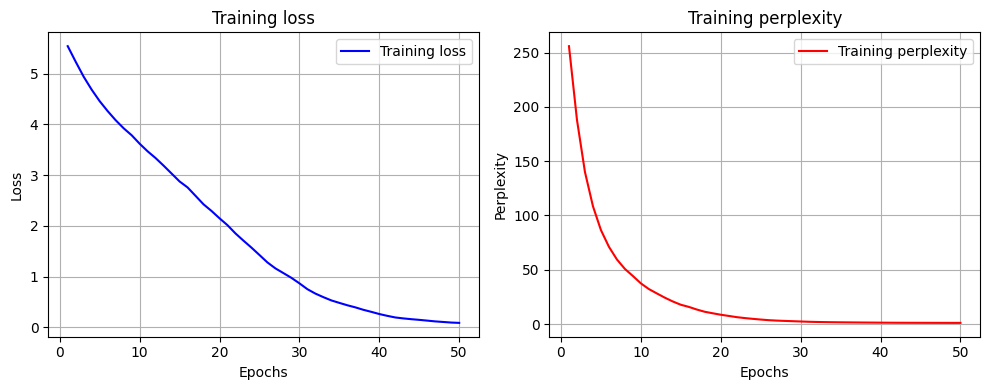

In [ ]:
### Plot of loss function values versus the number of epochs

# Using perplexity as a performance metric
loss = history.history['loss']
perplex = history.history['perplexity']
plot_epochs = range(1, len(loss) + 1)

# Plot training loss and training perplexity
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plotting training loss
# "b" is for "solid blue line"
axes[0].plot(plot_epochs, loss, 'b', label='Training loss')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid()

# Plotting training perplexity: Note - the graphs would be the same if used plt.yscale(value='log')
# "b" is for "solid blue line"
axes[1].plot(plot_epochs, perplex, 'r', label='Training perplexity')
axes[1].set_title('Training perplexity')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

#### **Results vs in P2:**

- Using the decoder-only transformer (and keeping the learning rate = 1e-3), the model performed significantly better. Its training loss (0.0857) and training perplexity (1.0896, very close to 1) decrease steadily and are very low after 50 epochs.
- Training perplexity being near 1 means that the next words generated after the initial word "Alice" are much closer to being the "correct" coherent word, rather than having a higher probability of having a mismatched/incoherent word.
- The words after 50 epochs can create reasonable sentences, once adding punctuations and symbols back in. For example, the first half with punctuation is:
  - *Alice waited patiently until it chose to speak again **.** in a minute or two **,** the caterpillar took the hookah out of its mouth and yawned once or twice and shook itself **.** then it got down off the mushroom and crawled away in the grass **,** merely remarking as it went one way...*
- With more epochs or tweaks to the transformer or modelling parameters, the results could further marginally improve, though its performance is already significantly better.

### **P3.2:**

Use a (not excessively large) pre-trained transformer for the language modelling instead of your model trained from scratch. Does fine-tuning (for a few epochs) on the current corpus help? Compare the results with the other word-level language models from the assignment.

In [4]:
### Create dataset for keras_nlp using presets
batch_size = 2
dataset_gpt2 = tf.data.Dataset.from_tensor_slices(lines).shuffle(1000).batch(batch_size) # use smaller batch size

In [9]:
### Pre-trained transformer model
model_gpt2 = keras_nlp.models.GPT2CausalLM.from_preset("gpt2_base_en")

# Compile the model
# perplexity = keras_hub.metrics.Perplexity(mask_token_id=0, name="perplexity", normalize=True) # need to normalize to avoid explosion
opt = tf.keras.optimizers.Adam(learning_rate=1e-4) # using 1e-4 instead of 1e-3
model_gpt2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # need from_logits=True since not specifying output layer activation function
                   optimizer=opt) # , metrics=[perplexity]
model_gpt2.summary()

Preprocessor: "gpt2_causal_lm_preprocessor_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gpt2_tokenizer (GPT2Tokenizer)                                │                       Vocab size: 50,257 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gpt2_causal_lm_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gpt2_backbone (GPT2Backbone)  │ (None, None, 768)         │     124,439,808 │ padding_mask[0][0],        │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 50257)       │      38,597,376 │ gpt2_backbone[0][0]        │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 124,439,808 (474.70 MB)

 Trainable params: 124,439,808 (474.70 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
### Fine-tuning on a few epochs
history = model_gpt2.fit(dataset_gpt2, epochs=3)

Epoch 1/3
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 1256s 624ms/step - loss: 0.0396 - sparse_categorical_accuracy: 0.2668
Epoch 2/3
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 1134s 602ms/step - loss: 0.0302 - sparse_categorical_accuracy: 0.3673
Epoch 3/3
1881/1881 ━━━━━━━━━━━━━━━━━━━━ 1133s 601ms/step - loss: 0.0232 - sparse_categorical_accuracy: 0.4758


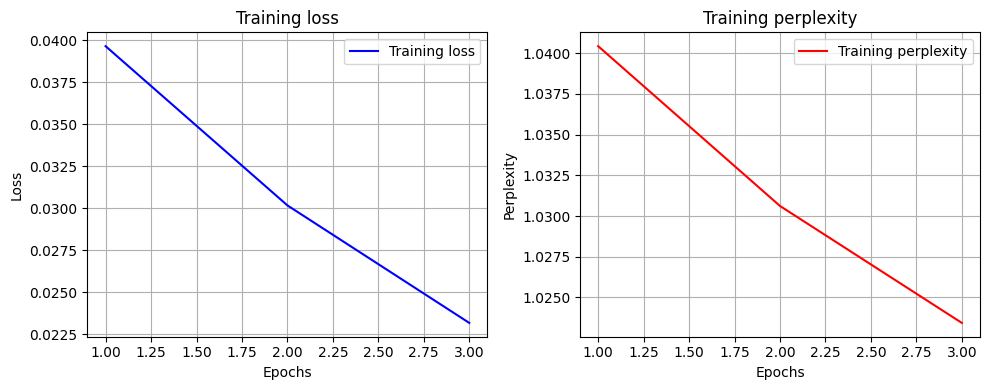

In [14]:
### Plot of loss function values versus the number of epochs

# Using perplexity as a performance metric
loss = history.history['loss']
perplexities = [np.exp(l) for l in loss] # Calculate perplexity for each epoch
plot_epochs = range(1, len(loss) + 1)

# Plot training loss and training perplexity
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plotting training loss
# "b" is for "solid blue line"
axes[0].plot(plot_epochs, loss, 'b', label='Training loss')
axes[0].set_title('Training loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid()

# Plotting training perplexity: Note - the graphs would be the same if used plt.yscale(value='log')
# "b" is for "solid blue line"
axes[1].plot(plot_epochs, perplexities, 'r', label='Training perplexity')
axes[1].set_title('Training perplexity')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [18]:
### Test out the model to generate output
output = model_gpt2.generate("Alice", max_length=100)
print(output)

Alice in Wonderland and the gryphon said with a very grave voice


In [43]:
for i in range(0,10):
  output = model_gpt2.generate("Alice", max_length=100)
  print(output)

Alice and to alice as well as the three creatures
Alice
Alice
Alice in Wonderland
Alice and the gryphon said very solemnly in an offended tone
Alice in a teacup and the king was sitting on his throne with one
Alice s adventures first
Alice in Wonderland
Alice in Wonderland
Alice and what are they made of alice and how did you manage to


#### **Results:**

- After a few epochs, the training loss and training perplexity both declined, but the training time was immensely long compared to the other models before, as it has >124M parameters.
- After a few fine-tuning epochs, it generated text that wasn't as good as the better GRU models or the custom transformer model from P3.1.
- Though it has the potential to improve, given the training time and computational itensity, it wouldn't be worth using this version of the model to generate this text.